<a href="https://colab.research.google.com/github/Rhuan-Messias/T-picosIA/blob/main/v2_ml_cat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd
import os
import shutil
from PIL import Image
from IPython.display import clear_output

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [3]:
# 1. Configuração do Modelo e Pastas
model = ResNet50(weights='imagenet')
historico_resultados = []
if os.path.exists("uploads"): shutil.rmtree("uploads")
os.makedirs("uploads", exist_ok=True)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
# 2. Carregar o Dataset (100 imagens)
dataset_raw, info = tfds.load('cats_vs_dogs', split='train[:100]', with_info=True, as_supervised=True)

print("💾 Salvando imagens do dataset localmente para processamento...")
for i, (img_tensor, label) in enumerate(dataset_raw):
    # Definir nome do arquivo baseado no label real (1=gato, 0=cachorro)
    prefixo = "gato" if label == 1 else "nao_gato"
    filename = f"{prefixo}_{i}.jpg"
    img_path = os.path.join("uploads", filename)

    # Salvar o tensor como arquivo de imagem
    img_np = img_tensor.numpy().astype(np.uint8)
    Image.fromarray(img_np).save(img_path)

print("✅ Setup pronto e 100 imagens preparadas na pasta 'uploads'!")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.QIUS1I_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
💾 Salvando imagens do dataset localmente para processamento...
✅ Setup pronto e 100 imagens preparadas na pasta 'uploads'!


In [7]:
from IPython.display import clear_output

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    # .copy() para evitar o erro de 'read-only' que vimos antes
    img_array = np.expand_dims(img_array, axis=0).copy()
    return preprocess_input(img_array)

def extract_label(filename):
    return "gato" if filename.lower().startswith("gato") else "nao_gato"

cat_labels = ['tabby', 'tiger_cat', 'persian_cat', 'siamese_cat', 'egyptian_cat', 'cat', 'domestic_cat']

print("🔍 Iniciando classificação das 100 imagens...")

# Listar todos os arquivos da pasta uploads
arquivos = [f for f in os.listdir("uploads") if f.endswith(".jpg")]

for filename in arquivos:
    img_path = os.path.join("uploads", filename)
    try:
        img_array = load_and_preprocess_image(img_path)
        preds = model.predict(img_array, verbose=0)
        decoded = decode_predictions(preds, top=1)[0]

        label_imagenet = decoded[0][1]
        score = decoded[0][2]

        # Lógica de predição
        pred_gato = "gato" if any(cat in label_imagenet.lower() for cat in cat_labels) else "nao_gato"
        true_label = extract_label(filename)

        # Matriz de Confusão (TP, TN, FP, FN)
        if true_label == "gato":
            res = "TP" if pred_gato == "gato" else "FN"
        else:
            res = "TN" if pred_gato == "nao_gato" else "FP"

        historico_resultados.append({
            "Imagem": filename,
            "Rótulo Real": true_label,
            "Predição": pred_gato,
            "Confiança": f"{score*100:.1f}%",
            "Resultado": res
        })
    except Exception as e:
        print(f"❌ Erro em {filename}: {e}")

clear_output()
print(f"✅ Processamento concluído! {len(historico_resultados)} imagens analisadas.")

✅ Processamento concluído! 100 imagens analisadas.


In [8]:
if not historico_resultados:
    print("A tabela está vazia. Rode o Bloco 2 primeiro.")
else:
    df = pd.DataFrame(historico_resultados)
    display(df)
    print(f"\n📊 Resumo: {df['Resultado'].value_counts().to_dict()}")

,Imagem,Rótulo Real,Predição,Confiança,Resultado
0,gato_17.jpg,gato,nao_gato,70.5%,FN
1,nao_gato_87.jpg,nao_gato,nao_gato,27.8%,TN
2,gato_5.jpg,gato,nao_gato,26.9%,FN
3,gato_76.jpg,gato,nao_gato,92.5%,FN
4,nao_gato_79.jpg,nao_gato,nao_gato,36.4%,TN
...,...,...,...,...,...
95,nao_gato_71.jpg,nao_gato,nao_gato,19.8%,TN
96,gato_28.jpg,gato,nao_gato,53.1%,FN
97,gato_34.jpg,gato,nao_gato,96.6%,FN
98,gato_98.jpg,gato,nao_gato,38.7%,FN



📊 Resumo: {'FN': 53, 'FP': 29, 'TN': 17, 'TP': 1}


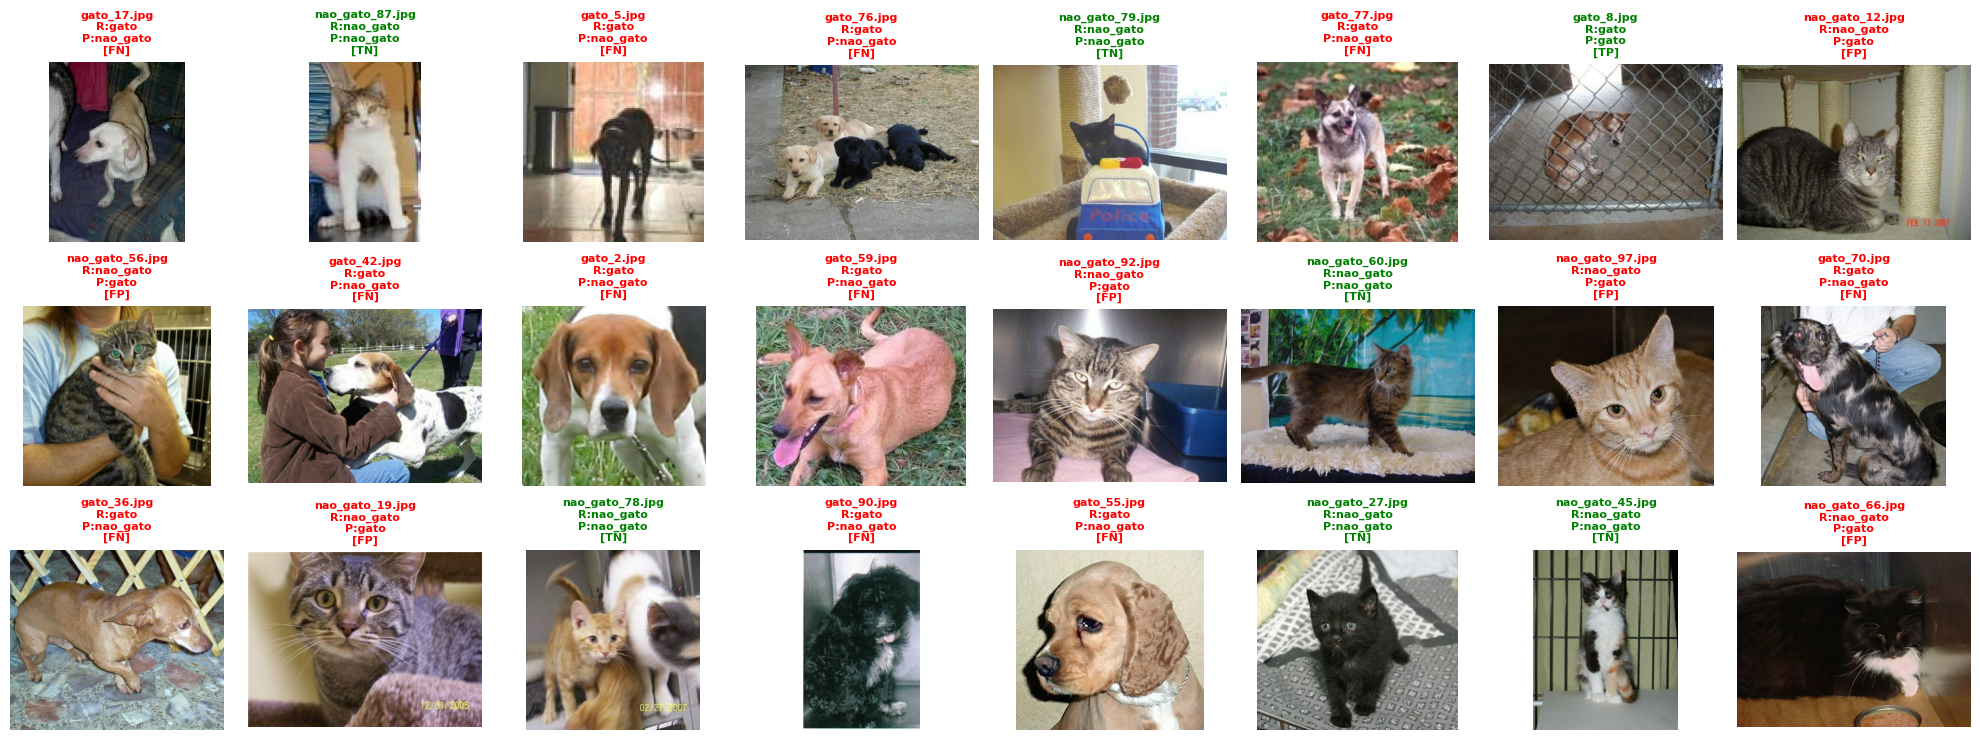

In [9]:
import matplotlib.pyplot as plt
import math

def visualizar_galeria(historico, imagens_por_linha=8):
    if not historico:
        print("⚠️ O histórico está vazio!")
        return

    total = len(historico)
    colunas = imagens_por_linha
    linhas = math.ceil(total / colunas)

    fig, axes = plt.subplots(linhas, colunas, figsize=(2.5 * colunas, 2.5 * linhas))
    axes = axes.flatten()

    for i in range(len(axes)):
        if i < total:
            item = historico[i]
            img_path = os.path.join("uploads", item['Imagem'])
            img = Image.open(img_path)
            axes[i].imshow(img)

            cor = 'red' if item['Resultado'] in ['FP', 'FN'] else 'green'
            titulo = f"{item['Imagem']}\nR:{item['Rótulo Real']}\nP:{item['Predição']}\n[{item['Resultado']}]"
            axes[i].set_title(titulo, color=cor, fontsize=8, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Como 100 imagens é muita coisa, vamos mostrar apenas as primeiras 24 na galeria
# Para ver todas, use visualizar_galeria(historico_resultados)
visualizar_galeria(historico_resultados[:24])

In [10]:
historico_resultados = []
if os.path.exists("uploads"):
    shutil.rmtree("uploads")
    os.makedirs("uploads")
clear_output()
print("🧹 SISTEMA RESETADO! Tudo limpo para uma nova execução.")

🧹 SISTEMA RESETADO! Tudo limpo para uma nova execução.
